# Figure 2c — Unproductive splicing events with concordant differential expression

Heatmap showing significant differential usage of unproductive splicing events
for genes that also show differential gene expression. Rows are unproductive
introns, z-scored across tissues and clustered into six row groups; columns are
the 50 GTEx tissues, clustered into three groups and colour-coded along the
bottom.

R kernel (`ir`). Sources: `../DS_Heatmap2.ipynb` and `../DS_Heatmap.ipynb`,
whose plotting cells are byte-identical; the duplicate was collapsed. The panel
was unnamed in those notebooks beyond a commented-out `fig2_heatmap.pdf`, and is
panel **c** of the published Figure 2.

Two versions are built, from the two fitted-PSI tables that
`../GetGTExTables.ipynb` writes:

| Panel | PSI table | Tissues | Saved as |
|---|---|---|---|
| **Fig. 2c** | `GTEx.psi.tsv.gz` (pre-confounder) | 50 | `plots/fig2c.*` |
| **Fig. 2c_confounders** | `GTEx.psi.confounder.tsv.gz` | 49 (no Bladder) | `plots/fig2c_confounders.*` |

`fig2c` reproduces the published panel exactly (4,073 introns x 50 tissues).
`fig2c_confounders` is the internally consistent version: the fitted PSI comes
from the same confounder run as the row selection, and Bladder — which is
excluded from the 1,176 pairwise comparisons that pick the rows — is dropped
from the columns too. Same 4,073 rows either way.

The PSI in these tables is fitted by `leafcutter_ds`, not counted raw, so adding
the confounder covariate shifts it slightly (median |Δ| = 0.002, correlation
0.9997) — hence two panels rather than one. Both write into `plots/`, the same
directory the Python notebooks in this folder use.

Run **cell 3** (and **cell 5** for the confounder version) once to build and
cache the matrices, then the plot cells. On later sessions, uncomment **cell 2**
and skip the build cells to re-plot from `figure_data/`.

The source cell also carried a commented-out `fig2_heatmap_aver.pdf`, built from
a gene-averaged matrix rather than a per-intron one. It gives the same figure, so
only the per-intron matrix is built here.

In [1]:
source('Figure2_heatmap_helpers.R')
source('Figure2_heatmap_plot_helpers.R')

In [2]:
# Fast path: re-plot straight from the .rds files written by run_all().
# Uncomment this cell and skip the build cells.

# data <- load_plot_data('figure_data')

# heatmap_X_introns            <- data$heatmap_X_introns
# heatmap_X_introns_confounder <- data$heatmap_X_introns_confounder

In [3]:
# Fig. 2c matrix, from the pre-confounder GTEx.psi.tsv.gz.
# Unions the significant unproductive clusters over every tissue pair from the
# ds_v_dge_confounder RDS files. Heavy: one RDS read per tissue pair.

data <- run_all('figure_data', psi_table = PSI_TABLE,
                var_name = 'heatmap_X_introns')

heatmap_X_introns <- data$heatmap_X_introns
dim(heatmap_X_introns)

[1] 4073   50

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



  fig2c_source_data.tsv          4073 introns x 50 tissues, 6 row groups
  fig2c_source_data.tissues.tsv  50 tissues, 3 column groups


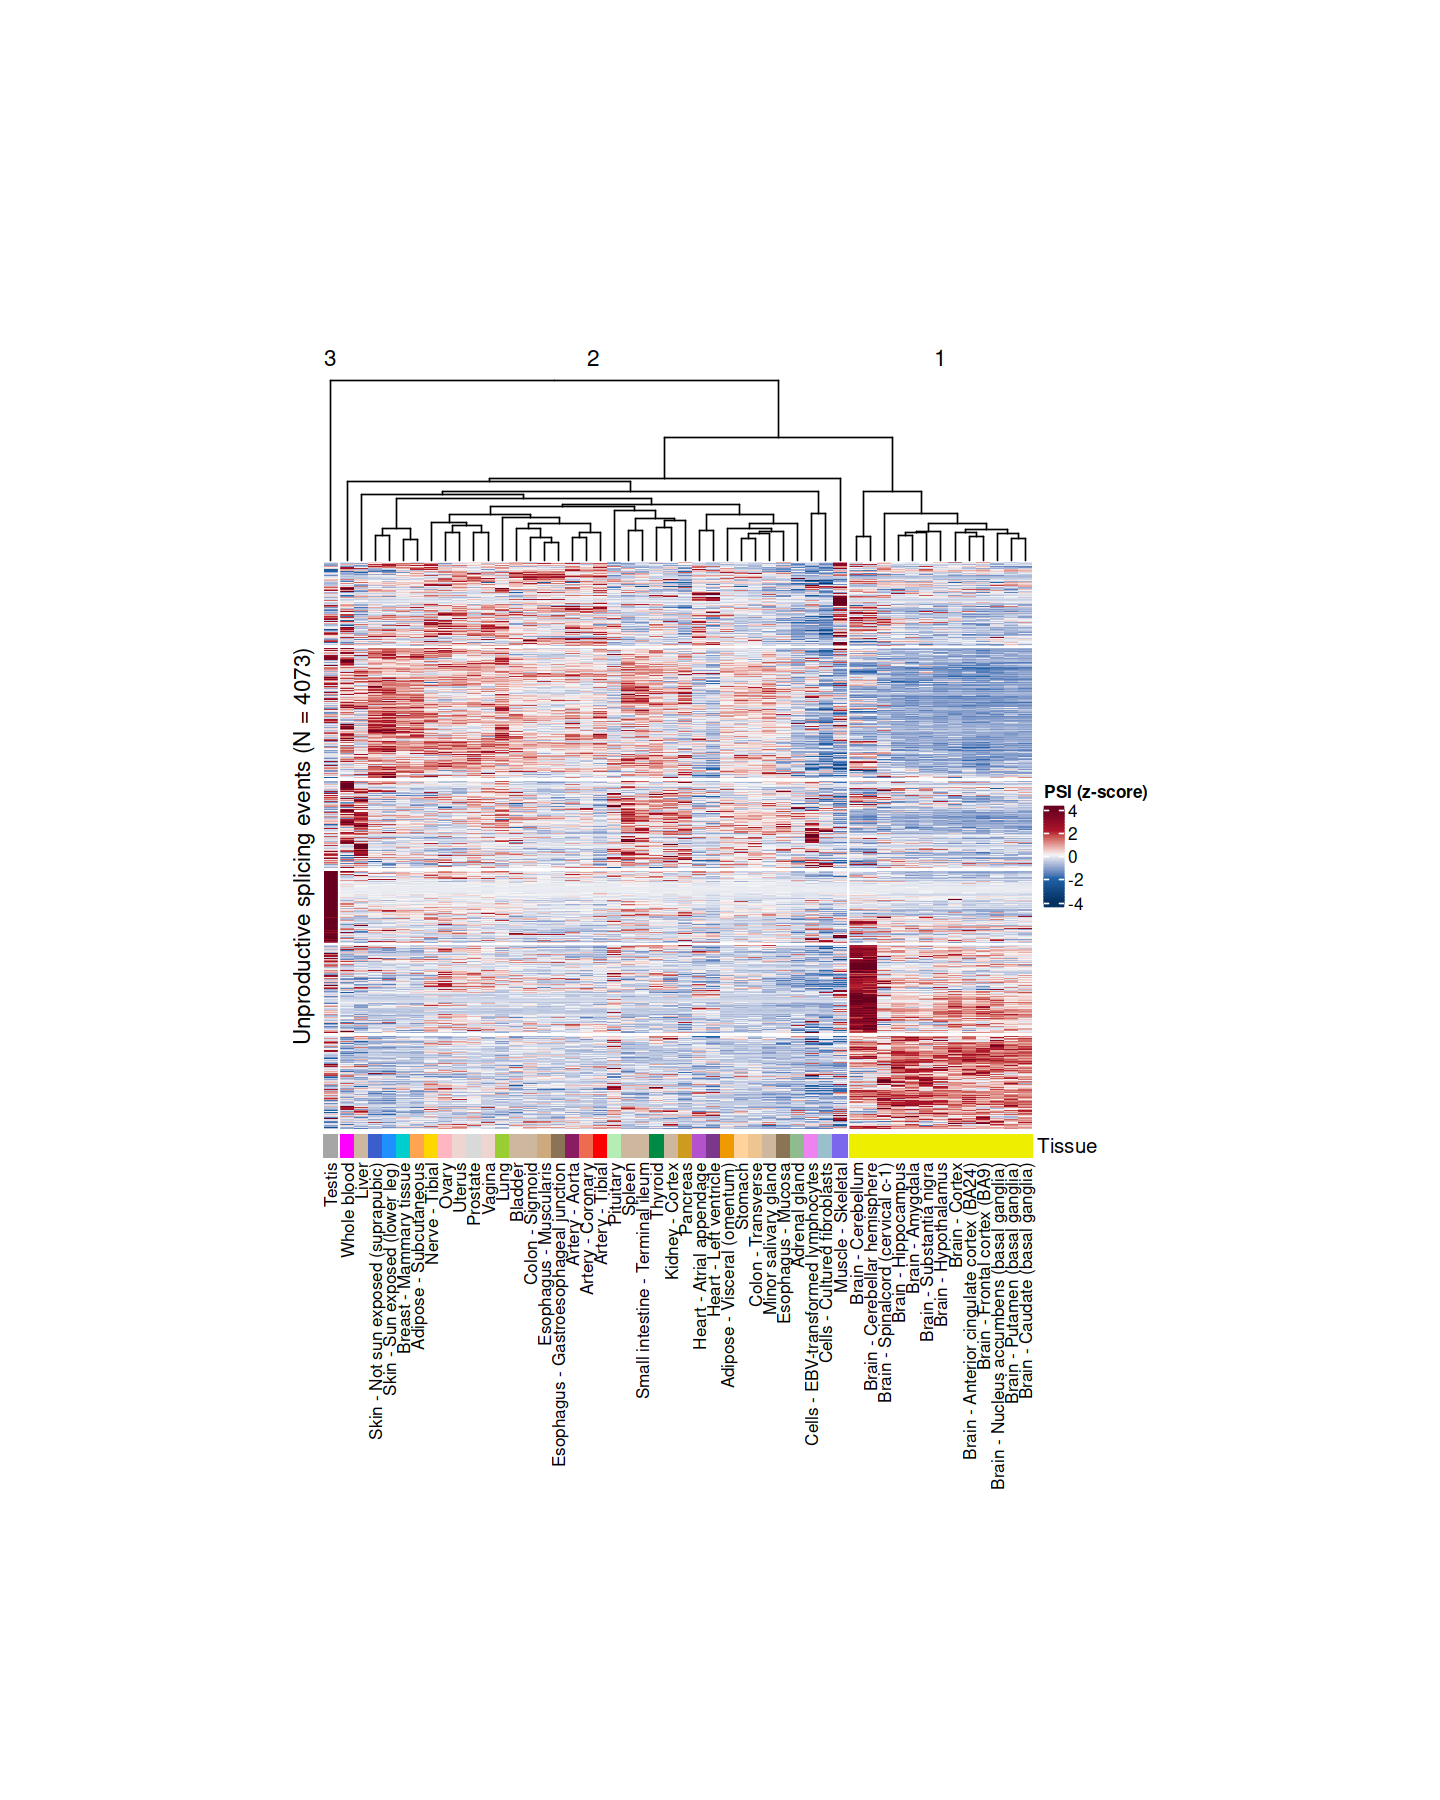

In [4]:
# Fig. 2c -- from DS_Heatmap.ipynb (the published thresholds: |dPSI| >= 0.1,
# FDR <= 10%, |log2FC| >= 1). One row per unproductive intron; 4,073 x 50.
# DS_Heatmap2.ipynb shares the plotting cell but uses stricter filters.

options(repr.plot.width = 12, repr.plot.height = 15)
ht <- plot_fig2_heatmap(heatmap_X_introns, gtex_colors, seed = 2)

save_fig2_heatmap(ht, file.path(PLOTS_DIR, 'fig2c.pdf'))

# Source data: gene, k-means row group, drawn position and the z-scored PSI
# actually plotted. The groups only exist once the heatmap is drawn.
save_heatmap_source_data(ht, heatmap_X_introns, 'figure_data/fig2c_source_data')

# UP_clusters.tsv -- the input analysis/GO_analysis.ipynb reads. Same rows and
# z-scores as the source data above, plus itype/ctype and the k-means group
# numbered by top-to-bottom position in the drawn figure (the paper's groups
# I-VI). Verified to reproduce code/analysis_files/UP_clusters.tsv: identical
# rows, order and Cluster column, and all 203,650 values bit-identical.
write_up_clusters(ht, heatmap_X_introns, 'figure_data/UP_clusters.tsv')

# The source notebook wrote this as fig2_heatmap.pdf:
# pdf("../code/plots/fig2_heatmap.pdf",  width = 12, height = 15)
# draw(ht, raster_quality = 2)
# dev.off()

## Fig. 2c_confounders — the internally consistent version

Same clusters and clustering seed as Fig. 2c. Two differences: the PSI is taken
from the confounder-corrected run (matching the run that selected the rows), and
Bladder is dropped from the columns to match the 49 tissues used for filtering.

In [5]:
# Fig. 2c_confounders matrix, from GTEx.psi.confounder.tsv.gz.
# Requires the last cell of ../GetGTExTables.ipynb to have been run.
#
# Bladder is dropped here. It takes no part in the 1,176 pairwise comparisons
# that select the rows (collect_sig_clusters excludes it), so keeping it as a
# column would colour a tissue that had no say in the selection. 49 columns,
# same 4,073 rows -- Bladder has no missing values in these introns, so nothing
# is gained or lost on the row axis.

data_conf <- run_all('figure_data', psi_table = PSI_TABLE_CONFOUNDER,
                     var_name = 'heatmap_X_introns_confounder',
                     exclude_tissues = EXCLUDE_TISSUES_CONFOUNDER)

heatmap_X_introns_confounder <- data_conf$heatmap_X_introns_confounder
dim(heatmap_X_introns_confounder)

[1] 4068   49

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



  fig2c_confounders_source_data.tsv          4068 introns x 49 tissues, 6 row groups
  fig2c_confounders_source_data.tissues.tsv  49 tissues, 3 column groups


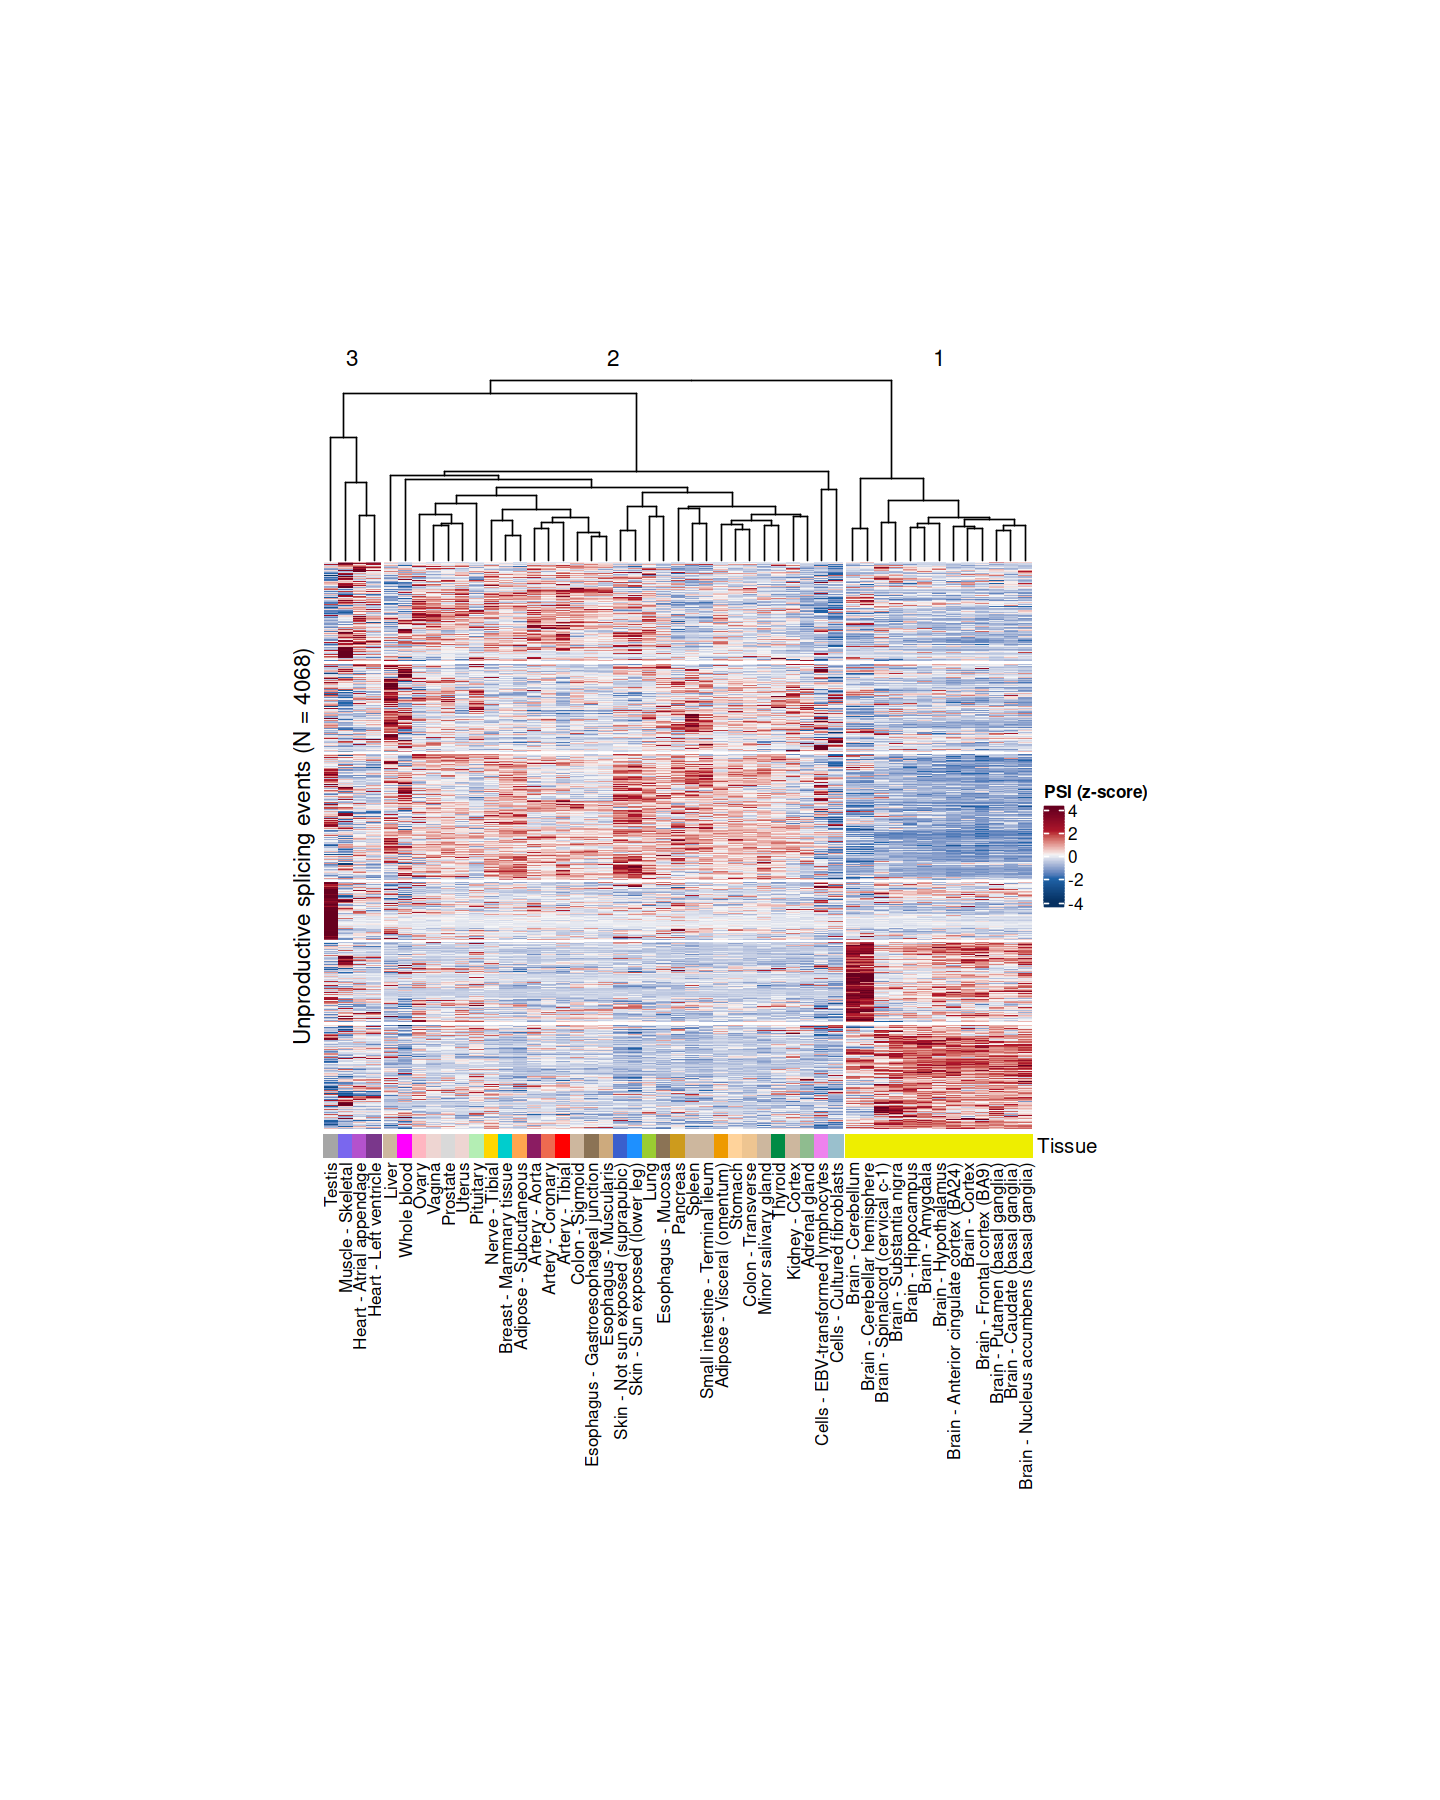

In [6]:
# Fig. 2c_confounders -- identical code to Fig. 2c, confounder-corrected PSI.

options(repr.plot.width = 12, repr.plot.height = 15)
ht_conf <- plot_fig2_heatmap(heatmap_X_introns_confounder, gtex_colors, seed = 1)

save_fig2_heatmap(ht_conf, file.path(PLOTS_DIR, 'fig2c_confounders.pdf'))

save_heatmap_source_data(ht_conf, heatmap_X_introns_confounder,
                         'figure_data/fig2c_confounders_source_data')

# The confounder-consistent counterpart of UP_clusters.tsv (4,068 introns x 49
# tissues; Bladder excluded). k-means is re-derived on this matrix, so the
# groups come out in a different figure order than the published panel.
#
# Cluster carries the MANUSCRIPT numbering (groups I-VI), assigned by tissue
# pattern rather than by figure order. Read top to bottom, this heatmap shows:
#
#   1st from top  skeletal muscle / heart / arteries   group V
#   2nd           liver / spleen                       group IV
#   3rd           skin / digestive system              group III
#   4th           testis                               group VI
#   5th           cerebellum                           group II
#   6th           brain                                group I
#
# This assignment is tied to seed = 1 above: change the seed and the figure
# order changes, so re-check the order before trusting these labels.
write_up_clusters(ht_conf, heatmap_X_introns_confounder,
                  'figure_data/UP_clusters.confounder.tsv',
                  group_labels   = c(5, 4, 3, 6, 2, 1),
                  group_patterns = c('skeletal muscle/heart and arteries',
                                     'liver/spleen',
                                     'skin/digestive system',
                                     'testis',
                                     'cerebellum',
                                     'brain'))

### The two `UP_clusters` files number their groups differently

Both recover the same six tissue patterns, but they use **different conventions
in the `Cluster` column**, so the numbers are not interchangeable.

| | `UP_clusters.tsv` | `UP_clusters.confounder.tsv` |
|---|---|---|
| panel | published Fig. 2c | confounder-consistent |
| seed | 2 | 1 |
| rows x tissues | 4,073 x 50 | 4,068 x 49 |
| `Cluster` means | position in the figure, top to bottom | the manuscript's group I-VI |
| `pattern` column | no | yes |

The correspondence, which happens to be the same in both panels:

| Pattern | figure position | manuscript group |
|---|---|---|
| skeletal muscle / heart / arteries | 1 | V |
| liver / spleen | 2 | IV |
| skin / digestive system | 3 | III |
| testis | 4 | VI |
| cerebellum | 5 | II |
| brain | 6 | I |

So testis is `Cluster == 4` in the published file but `Cluster == 6` in the
confounder file, and the brain groups are `(5, 6)` versus `(1, 2)`.
`GO_analysis.ipynb` hardcodes the published numbering; pointing it at the
confounder file without remapping would silently select the wrong gene sets.

The confounder file's `pattern` column names each group directly, which is the
safe thing to filter on: the figure order depends on the seed, so any numbering
derived from it has to be re-checked whenever the seed changes.